In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau, kruskal, mannwhitneyu, f_oneway


from itertools import combinations

In [2]:
URL_DATA_ANA = "/home/edgar/GitHub/Proyectos/Datathon_2026/Data/datos_analisis"

In [3]:
# Leer el archivo excel (puedes especificar la hoja con sheet_name)
df = pd.read_excel(URL_DATA_ANA + "/metereologia.xlsx")

df_ventas_mensual = pd.read_excel(URL_DATA_ANA + "/ventas_asistencia_mensual.xlsx")

df_ventas = pd.read_excel(URL_DATA_ANA + "/ventas_asistencia.xlsx")

df_partidos = pd.read_excel(URL_DATA_ANA + "/partidos.xlsx")

df_turismo_mensual = pd.read_excel(URL_DATA_ANA + "/turismo_mensual.xlsx")

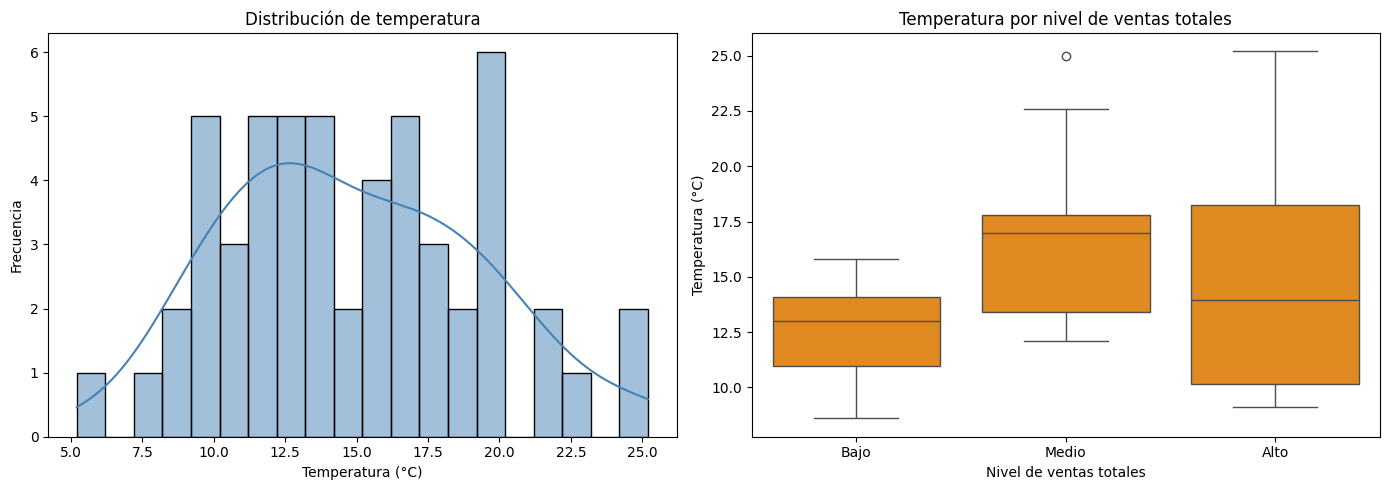

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="temp_c", kde=True, bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de temperatura")
axes[0].set_xlabel("Temperatura (°C)")
axes[0].set_ylabel("Frecuencia")

df_temp_ventas = df[["fecha", "temp_c"]].merge(
    df_ventas[["fecha", "nivel_ventas_totales"]], on="fecha", how="inner"
)
orden_niveles = ["Bajo", "Medio", "Alto"]
sns.boxplot(
    data=df_temp_ventas,
    x="nivel_ventas_totales",
    y="temp_c",
    order=orden_niveles,
    ax=axes[1],
    color="darkorange",
)
axes[1].set_title("Temperatura por nivel de ventas totales")
axes[1].set_xlabel("Nivel de ventas totales")
axes[1].set_ylabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

In [5]:
# Unir temperatura con variables de ventas por fecha
df_corr = df[["fecha", "temp_c"]].merge(
    df_ventas[["fecha", "asistencia total", "nivel_ventas_totales"]],
    on="fecha",
    how="inner",
)

# Codificar nivel de ventas para tests ordinales
mapa_nivel = {"Bajo": 1, "Medio": 2, "Alto": 3}
df_corr["nivel_ventas_cod"] = df_corr["nivel_ventas_totales"].map(mapa_nivel)

# Eliminar posibles nulos
df_corr = df_corr.dropna(subset=["temp_c", "asistencia total", "nivel_ventas_cod"]).copy()

# Tests con variable numérica continua (temperatura vs asistencia total)
r_pearson, p_pearson = pearsonr(df_corr["temp_c"], df_corr["asistencia total"])
r_spear_num, p_spear_num = spearmanr(df_corr["temp_c"], df_corr["asistencia total"])

# Tests con variable ordinal (temperatura vs nivel de ventas)
r_spear_ord, p_spear_ord = spearmanr(df_corr["temp_c"], df_corr["nivel_ventas_cod"])
tau_kendall, p_kendall = kendalltau(df_corr["temp_c"], df_corr["nivel_ventas_cod"])

orden_niveles = ["Bajo", "Medio", "Alto"]
grupos_temp = [
    df_corr.loc[df_corr["nivel_ventas_totales"] == nivel, "temp_c"].dropna()
    for nivel in orden_niveles
]
grupos_validos = [g for g in grupos_temp if len(g) > 0]

# Kruskal-Wallis: compara la distribución de temperatura entre niveles de ventas
h_kruskal, p_kruskal = kruskal(*grupos_validos)

# ANOVA de una vía como contraste paramétrico
f_anova, p_anova = f_oneway(*grupos_validos)

resultados = pd.DataFrame(
    {
        "test": [
            "Pearson (temp vs asistencia total)",
            "Spearman (temp vs asistencia total)",
            "Spearman (temp vs nivel ventas ordinal)",
            "Kendall tau (temp vs nivel ventas ordinal)",
            "Kruskal-Wallis (temp por nivel de ventas)",
            "ANOVA 1 vía (temp por nivel de ventas)",
        ],
        "estadistico": [r_pearson, r_spear_num, r_spear_ord, tau_kendall, h_kruskal, f_anova],
        "p_value": [p_pearson, p_spear_num, p_spear_ord, p_kendall, p_kruskal, p_anova],
    }
)
resultados["significativo_0.05"] = resultados["p_value"] < 0.05

# Post-hoc no paramétrico: Mann-Whitney U por pares con corrección Holm
pares = []
for g1, g2 in combinations(orden_niveles, 2):
    x = df_corr.loc[df_corr["nivel_ventas_totales"] == g1, "temp_c"].dropna()
    y = df_corr.loc[df_corr["nivel_ventas_totales"] == g2, "temp_c"].dropna()
    if len(x) > 0 and len(y) > 0:
        u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
        pares.append({"comparacion": f"{g1} vs {g2}", "U": u_stat, "p_value": p_val})

posthoc = pd.DataFrame(pares)

# Corrección Holm-Bonferroni (implementación manual)
if not posthoc.empty:
    posthoc = posthoc.sort_values("p_value").reset_index(drop=True)
    m = len(posthoc)
    holm_adj = []
    for i, p in enumerate(posthoc["p_value"], start=1):
        holm_adj.append(min((m - i + 1) * p, 1.0))
    for i in range(1, m):
        holm_adj[i] = max(holm_adj[i], holm_adj[i - 1])
    posthoc["p_holm"] = holm_adj
    posthoc["significativo_0.05"] = posthoc["p_holm"] < 0.05

print("Resumen de tests globales")
display(resultados.round(4))

print("Post-hoc Mann-Whitney U (corrección Holm)")
display(posthoc.round(4))

print(f"Observaciones usadas: {len(df_corr)}")

Resumen de tests globales


,test,estadistico,p_value,significativo_0.05
0,Pearson (temp vs asistencia total),-0.2098,0.2062,False
1,Spearman (temp vs asistencia total),-0.2698,0.1015,False
2,Spearman (temp vs nivel ventas ordinal),0.1405,0.4000,False
3,Kendall tau (temp vs nivel ventas ordinal),0.1208,0.3478,False
4,Kruskal-Wallis (temp por nivel de ventas),6.9988,0.0302,True
5,ANOVA 1 vía (temp por nivel de ventas),3.7871,0.0324,True


Post-hoc Mann-Whitney U (corrección Holm)


,comparacion,U,p_value,p_holm,significativo_0.05
0,Bajo vs Medio,23.5,0.0059,0.0177,True
1,Medio vs Alto,121.0,0.1522,0.3044,False
2,Bajo vs Alto,60.0,0.3664,0.3664,False


Observaciones usadas: 38


In [6]:
from pathlib import Path

csv_dir = Path("csv")
csv_dir.mkdir(exist_ok=True)

exports = {
    "df": df,
    "df_ventas_mensual": df_ventas_mensual,
    "df_ventas": df_ventas,
    "df_partidos": df_partidos,
    "df_turismo_mensual": df_turismo_mensual,
    "df_temp_ventas": df_temp_ventas,
    "df_corr": df_corr,
    "resultados": resultados,
    "posthoc": posthoc,
}

for nombre, frame in exports.items():
    frame.to_csv(csv_dir / f"{nombre}.csv", index=False)

print(f"Guardados {len(exports)} CSV en: {csv_dir.resolve()}")

Guardados 9 CSV en: /home/edgar/GitHub/Proyectos/Datathon_2026/archive_py/csv


# MODELO PREDICTIVO


In [ ]:
import pandas as pd
from pathlib import Path

# Usamos Path para manejar las rutas de forma nativa
URL_DATA_PRED = Path("/home/edgar/GitHub/Proyectos/Datathon_2026/Data/datos_predictivo")

df_partidos_pred = pd.read_excel(URL_DATA_PRED / "partidos.xlsx")
df_distancias = pd.read_csv(URL_DATA_PRED / "distancias.csv", sep=";", encoding="latin1")
df_met = pd.read_excel(URL_DATA_PRED / "metereologia.xlsx")
df_asistencia = pd.read_excel(URL_DATA_PRED / "asistencia.xlsx")

# Concatenación horizontal
df_pred = pd.concat(
    [
        df_partidos_pred,
        df_distancias,
        df_met,
        df_asistencia,
    ],
    axis=1,
)

df_para_prediccion = df_pred.copy()

# Eliminar las últimas 6 filas
df_pred = df_pred.iloc[:-6].copy()

# Eliminar columnas específicas
df_pred = df_pred.drop(
    columns=[
        "jornada",
        "temporada",
        "fecha",
        "equipo_visitante",
        "nº entradas zona visitante",
        "nº entradas partido",
        "asistencia abonados",
    ],
    errors="ignore",
)

# Mantener solo una columna por cada nombre repetido
df_pred = df_pred.loc[:, ~df_pred.columns.duplicated()].copy()

display(df_pred)
print(f"Filas resultantes: {len(df_pred)}")
print(f"Columnas combinadas: {len(df_pred.columns)}")

,hora,ptos_al_ascenso,posicion_liga_sporting,posicion_liga_rival,goles_acumulados_sporting,goles_balance_sporting,ptos_acumulados_sporting,ganados_sporting,empatados_sporting,perdidos_sporting,...,festivo_o_puente,partido_en_sabado,dist_a_gijon_km,temp_c,humedad_pct,dir_viento_deg,vel_viento_kmh,presion_hpa,cond_tiempo,asistencia total
0,19:30:00,3,20,2,0,-2,0,0,0,1,...,0,0,238.51,21.6,89,44,9.3,1022.4,Lluvia ligera,16765.0
1,16:15:00,3,14,11,3,-1,3,1,0,2,...,0,1,206.47,17.1,93,30,5.5,1014.8,Lluvia,16053.0
2,21:00:00,1,10,4,5,0,7,2,1,2,...,0,0,1923.20,16.7,73,152,7.4,1006.6,Nublado,13847.0
3,21:30:00,0,6,16,8,2,14,4,2,2,...,0,0,717.82,16.7,96,84,5.5,1024.6,Parcialmente despejado,13432.0
4,18:30:00,2,8,3,12,3,17,5,2,3,...,1,1,442.44,15.9,90,48,9.3,1022.9,Lluvia ligera,19140.0
5,18:30:00,1,8,3,17,5,21,6,3,3,...,0,1,684.62,18.6,59,198,9.3,995.3,Lluvia ligera,18096.0
6,21:00:00,-3,2,21,22,10,27,8,3,3,...,0,1,237.84,16.4,75,275,14.8,1011.4,Nublado,17083.0
7,21:00:00,-2,3,10,23,10,29,8,5,3,...,0,0,693.81,10.7,100,281,7.4,1016.5,Lluvia ligera,13465.0
8,18:30:00,-2,2,10,25,11,32,9,5,4,...,1,1,629.76,17.2,76,297,13.0,1020.1,Nublado,17858.0
9,18:30:00,-2,3,1,25,11,33,9,6,4,...,0,1,388.85,9.2,80,71,5.5,1037.3,Despejado,18564.0


Filas resultantes: 54
Columnas combinadas: 35


In [ ]:
# Ingenieria de variables para enriquecer el set predictivo (sin fuga de informacion)
import numpy as np

df_feat = df_pred.copy()

# DataFrames base alineados con df_pred (ya se eliminaron 6 filas al final)
partidos_base = df_partidos_pred.iloc[:-6].copy()
dist_base = df_distancias.iloc[:-6].copy()
met_base = df_met.iloc[:-6].copy()


def _norm(s):
    return str(s).strip().lower().replace(" ", "_")


def _find_col(df, candidates):
    cols_map = {_norm(c): c for c in df.columns}
    for cand in candidates:
        c = cols_map.get(_norm(cand))
        if c is not None:
            return c
    return None


# =========================
# 0) Evitar fuga de informacion (target leakage)
# =========================
# Excluir objetivo y columnas claramente derivadas del objetivo
leak_terms = [
    "asistencia_total",
    "nivel_ventas_totales",
    "ventas_totales",
    "target",
    "label",
]

leak_cols = [c for c in df_feat.columns if any(term in _norm(c) for term in leak_terms)]

if leak_cols:
    df_feat = df_feat.drop(columns=leak_cols, errors="ignore")
    print("Columnas excluidas por leakage:", leak_cols)

# =========================
# 1) Variables temporales
# =========================
col_fecha = _find_col(partidos_base, ["fecha", "date", "dia", "día"])
if col_fecha is not None:
    fechas = pd.to_datetime(partidos_base[col_fecha], errors="coerce")
    df_feat["mes"] = fechas.dt.month
    df_feat["trimestre"] = fechas.dt.quarter
    df_feat["dia_semana"] = fechas.dt.dayofweek
    df_feat["es_fin_de_semana"] = (fechas.dt.dayofweek >= 5).astype("Int64")

    # Codificacion ciclica (captura estacionalidad sin romper continuidad)
    df_feat["mes_sin"] = np.sin(2 * np.pi * df_feat["mes"] / 12)
    df_feat["mes_cos"] = np.cos(2 * np.pi * df_feat["mes"] / 12)
    df_feat["dia_semana_sin"] = np.sin(2 * np.pi * df_feat["dia_semana"] / 7)
    df_feat["dia_semana_cos"] = np.cos(2 * np.pi * df_feat["dia_semana"] / 7)

# =========================
# 2) Variables climaticas
# =========================
col_temp = _find_col(met_base, ["temp_c", "temperatura", "temp_media", "temperature"])
col_hum = _find_col(met_base, ["humedad", "humidity", "humedad_relativa", "hum_rel"])
col_lluvia = _find_col(met_base, ["precipitacion", "precip_mm", "rain", "lluvia"])
col_viento = _find_col(met_base, ["viento_kmh", "wind_kmh", "vel_viento", "wind_speed"])
col_tmax = _find_col(met_base, ["temp_max", "tmax", "temperatura_maxima"])
col_tmin = _find_col(met_base, ["temp_min", "tmin", "temperatura_minima"])

if col_temp is not None:
    t = pd.to_numeric(met_base[col_temp], errors="coerce")
    df_feat["temp_c"] = t
    df_feat["temp_c_2"] = t**2

if col_hum is not None and col_temp is not None:
    h = pd.to_numeric(met_base[col_hum], errors="coerce")
    t = pd.to_numeric(met_base[col_temp], errors="coerce")
    # Indice de incomodidad termica
    df_feat["indice_incomodidad"] = t - (0.55 - 0.0055 * h) * (t - 14.5)
    df_feat["temp_x_humedad"] = t * h

if col_tmax is not None and col_tmin is not None:
    tmax = pd.to_numeric(met_base[col_tmax], errors="coerce")
    tmin = pd.to_numeric(met_base[col_tmin], errors="coerce")
    df_feat["amplitud_termica"] = tmax - tmin

if col_lluvia is not None:
    r = pd.to_numeric(met_base[col_lluvia], errors="coerce")
    df_feat["lluvia_mm"] = r
    df_feat["lluvia_log1p"] = np.log1p(np.clip(r, a_min=0, a_max=None))
    df_feat["dia_lluvioso"] = (r > 0).astype("Int64")

if col_viento is not None:
    w = pd.to_numeric(met_base[col_viento], errors="coerce")
    df_feat["viento_kmh"] = w
    df_feat["viento_fuerte"] = (w >= 25).astype("Int64")

# =========================
# 3) Variables de distancia
# =========================
col_dist = _find_col(dist_base, ["distancia_km", "distancia", "km", "distance_km", "distance"])

if col_dist is not None:
    d = pd.to_numeric(dist_base[col_dist], errors="coerce")
    df_feat["distancia_km"] = d
    df_feat["distancia_log1p"] = np.log1p(np.clip(d, a_min=0, a_max=None))
    df_feat["viaje_largo"] = (d >= d.quantile(0.75)).astype("Int64")

# =========================
# 4) Codificacion de categoricas
# =========================
cat_cols = [
    c
    for c in df_feat.columns
    if (df_feat[c].dtype == "object" or str(df_feat[c].dtype).startswith("category"))
    and c not in leak_cols
]

# Frequency encoding para evitar alta cardinalidad en categoricas
for c in cat_cols[:8]:
    freq = df_feat[c].astype(str).value_counts(normalize=True)
    df_feat[f"{c}_freq"] = df_feat[c].astype(str).map(freq)

# =========================
# 5) Interacciones numericas
# =========================
num_cols = df_feat.select_dtypes(include=["number", "Int64", "Float64"]).columns.tolist()
num_cols = [c for c in num_cols if not c.endswith("_freq") and c not in leak_cols]

# Tomamos variables con mayor varianza para crear interacciones compactas
if len(num_cols) >= 2:
    var_rank = (
        df_feat[num_cols]
        .apply(pd.to_numeric, errors="coerce")
        .var(numeric_only=True)
        .sort_values(ascending=False)
        .index.tolist()
    )
    top_num = var_rank[:3]
    for i in range(len(top_num)):
        for j in range(i + 1, len(top_num)):
            a, b = top_num[i], top_num[j]
            x = pd.to_numeric(df_feat[a], errors="coerce")
            y = pd.to_numeric(df_feat[b], errors="coerce")
            df_feat[f"{a}_x_{b}"] = x * y
            df_feat[f"{a}_div_{b}"] = x / (y.replace(0, np.nan))

# =========================
# 6) Limpieza final
# =========================
df_feat = df_feat.loc[:, ~df_feat.columns.duplicated()].copy()

print(f"Variables base (sin target): {df_pred.shape[1] - len(leak_cols)}")
print(f"Variables tras ingenieria: {df_feat.shape[1]}")

nuevas = [c for c in df_feat.columns if c not in df_pred.columns]
print("Primeras nuevas variables:")
print(nuevas[:30])

display(df_feat)

Columnas excluidas por leakage: ['asistencia total']
Variables base (sin target): 34
Variables tras ingenieria: 50
Primeras nuevas variables:
['mes', 'trimestre', 'dia_semana', 'es_fin_de_semana', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos', 'temp_c_2', 'hora_freq', 'balance_verano  (miles)_x_balance_invierno (miles)', 'balance_verano  (miles)_div_balance_invierno (miles)', 'balance_verano  (miles)_x_dist_a_gijon_km', 'balance_verano  (miles)_div_dist_a_gijon_km', 'balance_invierno (miles)_x_dist_a_gijon_km', 'balance_invierno (miles)_div_dist_a_gijon_km']


,hora,ptos_al_ascenso,posicion_liga_sporting,posicion_liga_rival,goles_acumulados_sporting,goles_balance_sporting,ptos_acumulados_sporting,ganados_sporting,empatados_sporting,perdidos_sporting,...,dia_semana_sin,dia_semana_cos,temp_c_2,hora_freq,balance_verano (miles)_x_balance_invierno (miles),balance_verano (miles)_div_balance_invierno (miles),balance_verano (miles)_x_dist_a_gijon_km,balance_verano (miles)_div_dist_a_gijon_km,balance_invierno (miles)_x_dist_a_gijon_km,balance_invierno (miles)_div_dist_a_gijon_km
0,19:30:00,3,20,2,0,-2,0,0,0,1,...,-0.781831,0.623490,466.56,0.018519,0,NaN,0.00,0.000000,0.00,0.000000
1,16:15:00,3,14,11,3,-1,3,1,0,2,...,-0.974928,-0.222521,292.41,0.222222,0,NaN,103235.00,2.421659,0.00,0.000000
2,21:00:00,1,10,4,5,0,7,2,1,2,...,-0.781831,0.623490,278.89,0.203704,0,NaN,-9616.00,-0.002600,0.00,0.000000
3,21:30:00,0,6,16,8,2,14,4,2,2,...,0.974928,-0.222521,278.89,0.037037,0,NaN,11262595.80,21.857847,0.00,0.000000
4,18:30:00,2,8,3,12,3,17,5,2,3,...,-0.974928,-0.222521,252.81,0.333333,0,NaN,13273.20,0.067806,0.00,0.000000
5,18:30:00,1,8,3,17,5,21,6,3,3,...,-0.974928,-0.222521,345.96,0.333333,0,NaN,20264752.00,43.235664,0.00,0.000000
6,21:00:00,-3,2,21,22,10,27,8,3,3,...,-0.974928,-0.222521,268.96,0.203704,0,NaN,0.00,0.000000,0.00,0.000000
7,21:00:00,-2,3,10,23,10,29,8,5,3,...,0.000000,1.000000,114.49,0.203704,0,NaN,0.00,0.000000,0.00,0.000000
8,18:30:00,-2,2,10,25,11,32,9,5,4,...,-0.974928,-0.222521,295.84,0.333333,0,NaN,15019776.00,37.871570,0.00,0.000000
9,18:30:00,-2,3,1,25,11,33,9,6,4,...,-0.974928,-0.222521,84.64,0.333333,-120000,-3.000000,233310.00,1.543011,-77770.00,-0.514337


In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import IsolationForest

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError("Falta xgboost. Instala con: pip install xgboost") from e

# =========================================================
# 1. Preparar la variable objetivo (y) y alinear con X
# =========================================================
# Asumimos que df_asistencia ya está cargado en memoria
asistencia_base = (
    df_asistencia.copy()
)  # Usamos df_feat que ya tiene las filas alineadas con df_asistencia
target_col = _find_col(
    asistencia_base, ["asistencia total", "asistencia_total", "asistencia", "total_asistencia"]
)

if target_col is None:
    raise ValueError("No se encontró la columna objetivo de asistencia en df_asistencia.")

y = pd.to_numeric(asistencia_base[target_col], errors="coerce")
X = df_feat.copy()

# Filtrar filas donde la asistencia real sea nula
valid_mask = y.notna()
X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)

# =========================================================
# 2. Configurar la Validación Cruzada (LOGO o KFold)
# =========================================================
group_col = _find_col(X, ["equipo_local", "equipo", "club"])

if group_col is not None and X[group_col].nunique() > 1:
    groups = X[group_col].astype(str)
    cv = LeaveOneGroupOut()
    splits = list(cv.split(X, y, groups))
    estrategia_cv = f"Leave-One-Group-Out (agrupado por '{group_col}')"
else:
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    splits = list(cv.split(X, y))
    estrategia_cv = "K-Fold (5 particiones aleatorias)"

print(f"Estrategia de Validación: {estrategia_cv}")
print(f"Muestras a evaluar: {len(X)}")

# =========================================================
# 3. Definir el Pipeline de Preprocesamiento
# =========================================================
numeric_features = X.select_dtypes(include=[np.number, "Int64", "Float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

# Configuración base de XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
)

# =========================================================
# 4. Bucle de Entrenamiento y Evaluación
# =========================================================
fold_metrics = []

for fold_idx, (train_idx, test_idx) in enumerate(splits, start=1):
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    # --- FILTRADO DE ANOMALÍAS (ISOLATION FOREST) ---
    # Se aplica estrictamente solo a los datos numéricos de entrenamiento
    if len(numeric_features) > 0:
        # Imputación temporal rápida solo para que Isolation Forest pueda calcular distancias
        num_imp = SimpleImputer(strategy="median").fit_transform(X_train[numeric_features])

        # contamination=0.02 significa que eliminará el 2% de los partidos más extraños
        iso = IsolationForest(contamination=0.02, random_state=42)
        mask = iso.fit_predict(num_imp)
        inliers = np.where(mask == 1)[0]

        # Aplicar el filtro
        X_train = X_train.iloc[inliers].reset_index(drop=True)
        y_train = y_train.iloc[inliers].reset_index(drop=True)
        outliers_removidos = len(mask) - len(inliers)
    else:
        outliers_removidos = 0

    # --- PREPROCESAMIENTO DEFINITIVO ---
    X_train_trans = preprocessor.fit_transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # --- ENTRENAMIENTO Y PREDICCIÓN ---
    xgb_model.fit(X_train_trans, y_train)
    y_pred = xgb_model.predict(X_test_trans)

    # Evitar predicciones de asistencia negativas (físicamente imposibles)
    y_pred = np.clip(y_pred, a_min=0, a_max=None)

    # --- MÉTRICAS ---
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred) if len(np.unique(y_test)) > 1 else np.nan

    fold_metrics.append(
        {
            "Fold": fold_idx,
            "Outliers Eliminados": outliers_removidos,
            "N_Train": len(X_train),
            "N_Test": len(X_test),
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        }
    )

# =========================================================
# 5. Resumen de Resultados
# =========================================================
res_cv = pd.DataFrame(fold_metrics)

print("\n=========================================================")
print("🎯 RESULTADOS XGBOOST + ISOLATION FOREST 🎯")
print("=========================================================")
print(f"RMSE Promedio: {res_cv['RMSE'].mean():.2f} ± {res_cv['RMSE'].std():.2f}")
print(f"MAE Promedio : {res_cv['MAE'].mean():.2f} ± {res_cv['MAE'].std():.2f}")
print(f"R2 Promedio  : {res_cv['R2'].mean():.4f}")

print("\nDetalle de los 5 mejores Folds (menor RMSE):")
display(res_cv.sort_values("RMSE").head(5))

Estrategia de Validación: K-Fold (5 particiones aleatorias)
Muestras a evaluar: 54

🎯 RESULTADOS XGBOOST + ISOLATION FOREST 🎯
RMSE Promedio: 2424.56 ± 752.13
MAE Promedio : 1993.77 ± 566.02
R2 Promedio  : 0.1746

Detalle de los 5 mejores Folds (menor RMSE):


Estrategia de Validación: K-Fold (5 particiones aleatorias)
Muestras a evaluar: 54

🎯 RESULTADOS XGBOOST + ISOLATION FOREST 🎯
RMSE Promedio: 2424.56 ± 752.13
MAE Promedio : 1993.77 ± 566.02
R2 Promedio  : 0.1746

Detalle de los 5 mejores Folds (menor RMSE):


,Fold,Outliers Eliminados,N_Train,N_Test,RMSE,MAE,R2
2,3,1,42,11,1678.225700,1486.813354,0.292521
1,2,1,42,11,1778.404692,1459.576050,0.293234
4,5,1,43,10,2308.672995,1864.233643,0.377091
0,1,1,42,11,2916.744932,2442.879639,0.255629
3,4,1,42,11,3440.730300,2715.333740,-0.345339
